# Configuración de py5 en Google Colab

Este cuaderno explica cómo preparar el entorno de Google Colab para ejecutar sketches con py5. El proceso requiere instalar Java, algunas dependencias del sistema y la librería py5.

Solo es necesario ejecutar estas celdas **una vez por sesión**. Cada vez que Colab reinicia el entorno (lo cual ocurre automáticamente después de algunas horas de inactividad), hay que volver a correr la configuración desde el principio.

> **Nota:** A diferencia de la ejecución local, en Colab no vas a ver una ventana gráfica con el sketch. Las visualizaciones se capturan como imágenes estáticas usando `py5_tools.screenshot()`.

## Paso 1: Instalar Java

py5 necesita una máquina virtual de Java para funcionar, porque está construida sobre Processing, que es una plataforma basada en Java. La celda siguiente instala el JDK 17.

In [ ]:
# EN COLAB DESCOMENTAR ESTE CODIGO
#en visual studio code, no es necesario instalar jdk ni configurar JAVA_HOME, ya que py5 lo hace automáticamente al importar py5.


# !pip install install-jdk --quiet 

# import jdk
# import os

# java_path = jdk.install('17')
# os.environ['JAVA_HOME'] = java_path
# print('JAVA_HOME configurado en:', java_path)


## Paso 2: Instalar dependencias del sistema gráfico

Colab corre en un servidor Linux sin pantalla física. Para que py5 pueda generar imágenes, necesita un display virtual. El siguiente bloque instala las bibliotecas necesarias y levanta ese display.

In [19]:
#SOLO FUNCIONA EN COLAB, 
# EN VISUAL STUDIO CODE NO ES NECESARIO INSTALAR ESTOS PAQUETES, YA QUE PY5 LOS MANEJA AUTOMATICAMENTE.
!apt-get -qq install ca-certificates-java libxcursor1 libxrandr2 libxrender1 libxtst6 libxi6 xvfb > /dev/null

El sistema no puede encontrar la ruta especificada.


In [ ]:
#solo ejecutar en colab, 
# en visual studio code no es necesario configurar el display virtual, ya que py5 lo hace automáticamente al importar py5.

import os

# Iniciar el display virtual. Sin esto, py5 lanza un error de 'headless mode'.
!nohup /usr/bin/Xvfb :0 -screen 0 1024x768x24 &
os.environ['DISPLAY'] = ':0'
print('Display virtual configurado')

OSError: Background processes not supported.

## Paso 3: Instalar py5

Una aclaración importante: no instalar `py5[extras]`. Esa versión actualiza iPython y otros paquetes del entorno base de Colab, lo que provoca que la sesión se reinicie en un ciclo sin fin.

In [21]:
!pip install py5 --quiet

## Paso 4: Importar las librerías

Una vez que todo está instalado, importamos py5 y py5_tools. Esta última nos permite tomar capturas del sketch desde el cuaderno.

In [22]:
import py5
import py5_tools

## Verificación: primer sketch

Para confirmar que todo funciona, ejecutá las siguientes celdas en orden. Primero se define y corre el sketch, luego se captura una imagen y finalmente se detiene.

In [ ]:
def setup():
    py5.size(600, 600)
    for _ in range(100):
        py5.fill(py5.random_choice(('red', 'green', 'blue')), 100)
        py5.square(py5.random(50, 500), py5.random(50, 500), py5.random(10, 30))

py5.run_sketch()

#en visual studio code se abre la ventana y se ve la imagen
# en colab no se ve la imagen, 
# por eso se toma el screenshot, para poder ver el resultado del sketch. 

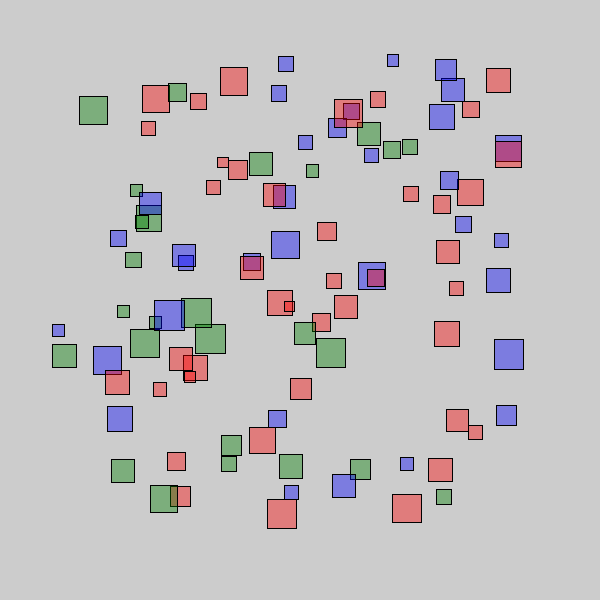

In [ ]:
# Captura una imagen del sketch en ejecución
py5_tools.screenshot()

#en vsc tomar el screenshot sin cerrar la ventana del sketch, para que se pueda seguir interactuando con ella.

In [25]:
# Detener el sketch para poder ejecutar el siguiente
py5.exit_sketch()

## Información de diagnóstico (opcional)

Si algo no funciona correctamente, la siguiente celda muestra información del entorno Java que puede ser útil para identificar el problema.

In [18]:
import py5_tools
py5_tools.jvm.get_jvm_debug_info()

{'JAVA_HOME environment variable': 'C:\\Program Files\\Java\\jdk-17',
 'jvm version': (17, 0, 17),
 'default jvm path': 'C:\\Program Files\\Java\\jdk-17\\bin\\server\\jvm.dll'}